# Portfolio Backtest

Calls `src/portfolio.py` functions. No logic lives here.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from src.portfolio import fetch_tbill_rates, run_all_model_backtests

## Load data

In [2]:
log_returns = pd.read_parquet(f'{config.DATA_RAW_DIR}/log_returns.parquet')
tickers = json.load(open(f'{config.DATA_RAW_DIR}/tickers.json'))
if config.DEV_UNIVERSE_SIZE is not None:
    tickers = tickers[:config.DEV_UNIVERSE_SIZE]
print(f'{len(tickers)} tickers, {len(log_returns)} trading days')

465 tickers, 2764 trading days


## Fetch T-bill rates from FRED

First run downloads DTB3 from FRED and saves to `data/raw/tbill_rates.parquet`. Subsequent runs load from disk.

In [3]:
tbill_rates = fetch_tbill_rates(start='2024-01-01', end=config.TEST_END)
print(f'T-bill rates: {len(tbill_rates)} daily observations')
print(f'Date range:   {tbill_rates.index[0].date()} to {tbill_rates.index[-1].date()}')
print(f'Mean annual rate (decimal): {tbill_rates.mean():.4f}  ({tbill_rates.mean()*100:.2f}%)')

T-bill rates: 731 daily observations
Date range:   2024-01-01 to 2025-12-31
Mean annual rate (decimal): 0.0500  (5.00%)


## Run portfolio backtest for all models

For each model, the prediction at test week T sets weights for the holding week T+1.
Actual portfolio returns are the realized stock log returns during week T+1.

In [4]:
portfolio_returns_df, metrics_table = run_all_model_backtests(
    log_returns_df=log_returns,
    tbill_rates=tbill_rates,
    tickers=tickers,
)
print('Saved: portfolio_returns.parquet, portfolio_metrics_table.csv')

Saved: portfolio_returns.parquet, portfolio_metrics_table.csv


## Portfolio metrics table

In [5]:
display_table = metrics_table.copy()
display_table['ann_return']  = display_table['ann_return'].map('{:.2%}'.format)
display_table['ann_vol']     = display_table['ann_vol'].map('{:.2%}'.format)
display_table['sharpe']      = display_table['sharpe'].map('{:.3f}'.format)
display_table['max_drawdown'] = display_table['max_drawdown'].map('{:.2%}'.format)
display_table['avg_turnover'] = display_table['avg_turnover'].map('{:.3f}'.format)
display_table['max_single_stock_weight'] = display_table['max_single_stock_weight'].map('{:.3f}'.format)
display_table.columns = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown',
                          'Avg Turnover', 'Max Weight']
display(display_table)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Avg Turnover,Max Weight
model,,,,,,
HAR per-stock,9.99%,12.61%,0.396,-15.48%,0.163,0.008
HAR pooled,10.18%,12.76%,0.406,-15.86%,0.152,0.005
LSTM,10.21%,12.67%,0.411,-15.80%,0.076,0.006
GNN-Correlation,9.69%,12.80%,0.367,-15.92%,0.074,0.023
GNN-Sector,10.27%,12.87%,0.410,-15.73%,0.072,0.016
GNN-Granger,10.46%,12.90%,0.423,-16.04%,0.082,0.004
Equal-weight,12.03%,13.70%,0.513,-17.07%,0.000,0.002


## Cumulative return plot

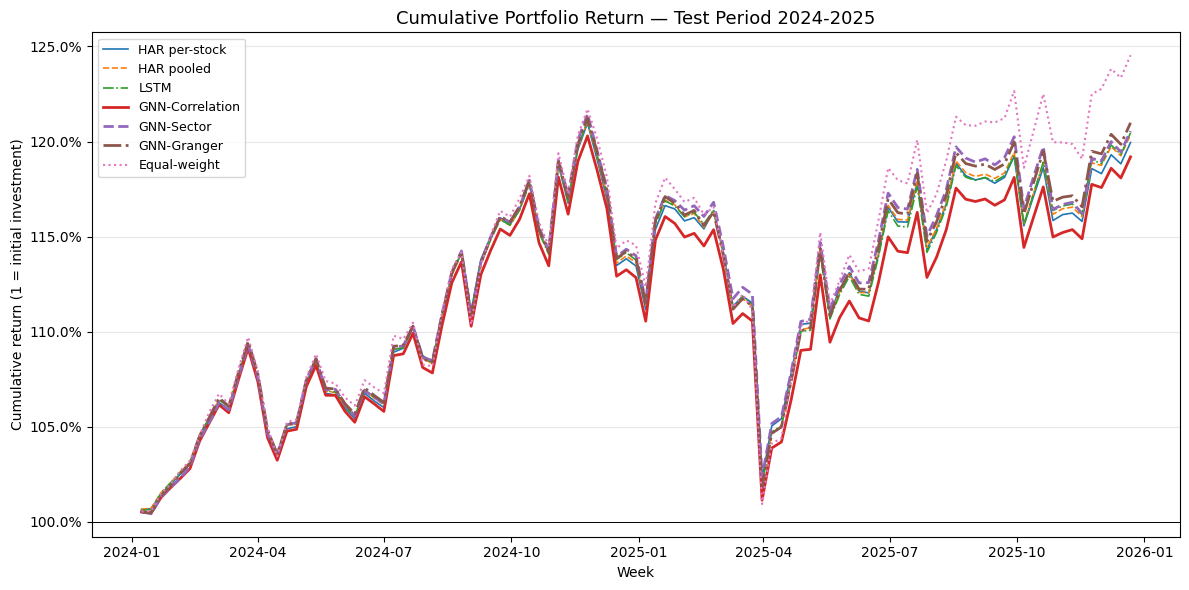

Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\portfolio_cumulative_return.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

model_order = [
    'HAR per-stock', 'HAR pooled', 'LSTM',
    'GNN-Correlation', 'GNN-Sector', 'GNN-Granger', 'Equal-weight',
]
linestyles = ['-', '--', '-.', '-', '--', '-.', ':']
linewidths  = [1.2, 1.2, 1.2, 2.0, 2.0, 2.0, 1.5]

for model, ls, lw in zip(model_order, linestyles, linewidths):
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    ax.plot(sub['week'].values, cum, label=model, linestyle=ls, linewidth=lw)

ax.axhline(1.0, color='black', linewidth=0.7, linestyle='-')
ax.set_title('Cumulative Portfolio Return — Test Period 2024-2025', fontsize=13)
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative return (1 = initial investment)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

import pathlib
fig_path = pathlib.Path(config.FIGURES_DIR) / 'portfolio_cumulative_return.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f'Saved figure: {fig_path}')

## Detailed statistics printout

In [7]:
SEP = '=' * 72

# 1. Raw metrics table (full precision)
print(SEP)
print('PORTFOLIO METRICS (raw numbers)')
print(SEP)
print(metrics_table.to_string())
print()

# 2. Ranking by each metric
print(SEP)
print('RANKINGS BY METRIC  (1 = best)')
print(SEP)
ranking_cols = {
    'ann_return':              False,   # higher is better
    'ann_vol':                 True,    # lower is better
    'sharpe':                  False,
    'max_drawdown':            False,   # less negative is better
    'avg_turnover':            True,    # lower is better
    'max_single_stock_weight': True,    # lower is better
}
ranks = pd.DataFrame({
    col: metrics_table[col].rank(ascending=asc).astype(int)
    for col, asc in ranking_cols.items()
})
ranks.columns = ['Ann Ret', 'Ann Vol', 'Sharpe', 'Max DD', 'Turnover', 'Max Wt']
ranks['avg_rank'] = ranks.mean(axis=1).round(2)
print(ranks.to_string())
print()

# 3. Per-model weekly return distributions
print(SEP)
print('WEEKLY NET RETURN DISTRIBUTIONS')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('week')
    r = sub['net_return'].values
    p = np.percentile(r, [5, 25, 50, 75, 95])
    n_pos = int((r > 0).sum())
    print(f'{model}')
    print(f'  mean={r.mean():.6f}  std={r.std(ddof=1):.6f}  min={r.min():.6f}  max={r.max():.6f}')
    print(f'  p5={p[0]:.6f}  p25={p[1]:.6f}  p50={p[2]:.6f}  p75={p[3]:.6f}  p95={p[4]:.6f}')
    print(f'  positive weeks: {n_pos}/{len(r)} ({100*n_pos/len(r):.1f}%)')
    print()

# 4. Five worst and best weeks per model
print(SEP)
print('5 WORST WEEKS  (by net return)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('net_return')
    print(f'{model}:')
    for _, row in sub.head(5).iterrows():
        print(f'  {row["week"].date()}  net={row["net_return"]:.4f}  '
              f'gross={row["gross_return"]:.4f}  turnover={row["turnover"]:.4f}')
    print()

print(SEP)
print('5 BEST WEEKS  (by net return)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('net_return', ascending=False)
    print(f'{model}:')
    for _, row in sub.head(5).iterrows():
        print(f'  {row["week"].date()}  net={row["net_return"]:.4f}  '
              f'gross={row["gross_return"]:.4f}  turnover={row["turnover"]:.4f}')
    print()

# 5. Drawdown details
print(SEP)
print('DRAWDOWN DETAILS  (peak-to-trough)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model].sort_values('week')
    cum = (1.0 + sub['net_return'].values).cumprod()
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max
    trough_idx = int(np.argmin(dd))
    peak_idx   = int(np.argmax(running_max[:trough_idx + 1]))
    weeks_arr  = sub['week'].values
    recovery   = np.where(dd[trough_idx:] >= 0)[0]
    rec_str = (
        f'{pd.Timestamp(weeks_arr[trough_idx + recovery[0]]).date()}  ({recovery[0]} weeks)'
        if len(recovery) > 0 else 'not recovered by end of test period'
    )
    print(f'{model}')
    print(f'  max drawdown:  {dd.min():.4f} ({dd.min()*100:.2f}%)')
    print(f'  peak:          {pd.Timestamp(weeks_arr[peak_idx]).date()}')
    print(f'  trough:        {pd.Timestamp(weeks_arr[trough_idx]).date()}')
    print(f'  recovery:      {rec_str}')
    print()

# 6. Turnover statistics
print(SEP)
print('TURNOVER STATISTICS  (weekly)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model]
    t = sub['turnover'].values
    ann_cost_bps = t.mean() * 52 * config.TRANSACTION_COST_BPS
    print(f'{model}:  mean={t.mean():.4f}  std={t.std(ddof=1):.4f}  '
          f'max={t.max():.4f}  ann_cost={ann_cost_bps:.2f} bps')
print()

# 7. Gross vs net return drag
print(SEP)
print('GROSS vs NET  (annualized)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model]
    gross_ann = sub['gross_return'].mean() * 52
    net_ann   = sub['net_return'].mean()   * 52
    drag_bps  = (gross_ann - net_ann) * 10_000
    print(f'{model}:  gross={gross_ann:.4f}  net={net_ann:.4f}  drag={drag_bps:.1f} bps/yr')
print()

# 8. Net-return correlation matrix across models
print(SEP)
print('WEEKLY NET-RETURN CORRELATION MATRIX')
print(SEP)
ret_wide = (
    portfolio_returns_df
    .pivot(index='week', columns='model', values='net_return')
    [model_order]
)
corr = ret_wide.corr()
short = ['HAR-ps', 'HAR-pl', 'LSTM', 'GNN-C', 'GNN-S', 'GNN-G', 'EW']
corr.index   = short
corr.columns = short
print(corr.round(3).to_string())
print()

# 9. Excess return vs equal-weight benchmark
print(SEP)
print('EXCESS NET RETURN VS EQUAL-WEIGHT')
print(SEP)
ew_returns = ret_wide['Equal-weight'].values
for model in model_order[:-1]:
    m_ret = ret_wide[model].values
    excess = m_ret - ew_returns
    pct_beat = 100 * (excess > 0).mean()
    print(f'{model}:  mean excess={excess.mean():+.6f}  '
          f'std={excess.std(ddof=1):.6f}  '
          f'beats EW {pct_beat:.1f}% of weeks')
print()

# 10. Weight concentration
print(SEP)
print('MAX SINGLE-STOCK WEIGHT  (mean / max / % weeks > 1%)')
print(SEP)
for model in model_order:
    sub = portfolio_returns_df[portfolio_returns_df['model'] == model]
    mw = sub['max_weight'].values
    pct_above = 100 * (mw > 0.01).mean()
    print(f'{model}:  mean={mw.mean():.4f}  max={mw.max():.4f}  '
          f'above 1%: {pct_above:.1f}% of weeks')

PORTFOLIO METRICS (raw numbers)
                 ann_return   ann_vol    sharpe  max_drawdown  avg_turnover  max_single_stock_weight
model                                                                                               
HAR per-stock      0.099884  0.126095  0.395608     -0.154781      0.163430                 0.007657
HAR pooled         0.101814  0.127620  0.406001     -0.158551      0.152096                 0.004916
LSTM               0.102099  0.126718  0.411143     -0.157998      0.075773                 0.005663
GNN-Correlation    0.096928  0.128020  0.366567     -0.159193      0.074094                 0.022972
GNN-Sector         0.102729  0.128707  0.409682     -0.157310      0.071850                 0.016102
GNN-Granger        0.104603  0.128960  0.423410     -0.160350      0.081782                 0.003899
Equal-weight       0.120309  0.137006  0.513179     -0.170673      0.000000                 0.002151

RANKINGS BY METRIC  (1 = best)
                 Ann Ret  A